In [1]:
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, balanced_accuracy_score
import uuid
import os
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image, ImageEnhance, ImageOps, ImageFilter

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)

2026-05-08 08:09:44.604845: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778227785.034956      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778227785.175135      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778227786.244804      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778227786.244855      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778227786.244857      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [2]:
DATASET_DIR = "/kaggle/input/datasets/malakdiab04/final-classification-dataset/FINAL_merged_filtered_for_translation"

IMG_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

SEED = 42

EPOCHS_HEAD = 20
EPOCHS_FINE = 35
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE = 2e-5

TEST_SIZE = 0.15
VAL_SIZE = 0.15

MODEL_NAME = "efficientnetv2b0"

USE_CLASS_WEIGHTS = False
USE_AUGMENTATION = True
USE_MIXUP=True
MIN_SAMPLES_PER_CLASS = 0


OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, IOError):
        return False

def scan_dataset(root_dir, verify_images=False):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Dataset directory not found: {root_dir}")

    records = []
    class_dirs = sorted([p for p in root.iterdir() if p.is_dir()])

    if len(class_dirs) == 0:
        raise ValueError("No class folders found in DATASET_DIR.")

    for class_dir in class_dirs:
        class_name = class_dir.name
        for file_path in class_dir.rglob("*"):
            if file_path.suffix.lower() in IMAGE_EXTS:
                if verify_images and not is_valid_image(file_path):
                    continue
                records.append((str(file_path), class_name))

    df = pd.DataFrame(records, columns=["filepath", "label"])
    return df

df = scan_dataset(DATASET_DIR, verify_images=False)

print("Total images before filtering:", len(df))
print("Number of classes before filtering:", df["label"].nunique())
display(df.head())

Total images before filtering: 15847
Number of classes before filtering: 718


,filepath,label
0,/kaggle/input/datasets/malakdiab04/final-class...,A1
1,/kaggle/input/datasets/malakdiab04/final-class...,A1
2,/kaggle/input/datasets/malakdiab04/final-class...,A1
3,/kaggle/input/datasets/malakdiab04/final-class...,A1
4,/kaggle/input/datasets/malakdiab04/final-class...,A1


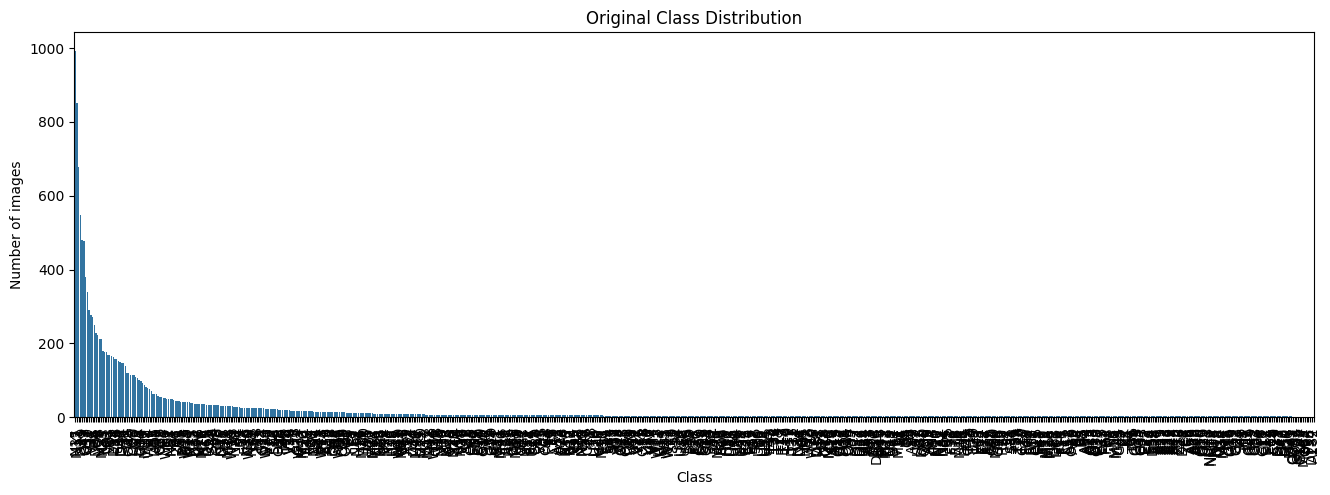

count    718.000000
mean      22.071031
std       74.310324
min        1.000000
25%        3.000000
50%        4.000000
75%        9.750000
max      993.000000
Name: count, dtype: float64


In [4]:
orig_counts = df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
sns.barplot(x=orig_counts.index.astype(str), y=orig_counts.values)
plt.title("Original Class Distribution")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.show()

print(orig_counts.describe())

,samples_in_class,number_of_classes
0,1,13
1,2,143
2,3,127
3,4,129
4,5,48
...,...,...
92,481,1
93,548,1
94,678,1
95,850,1


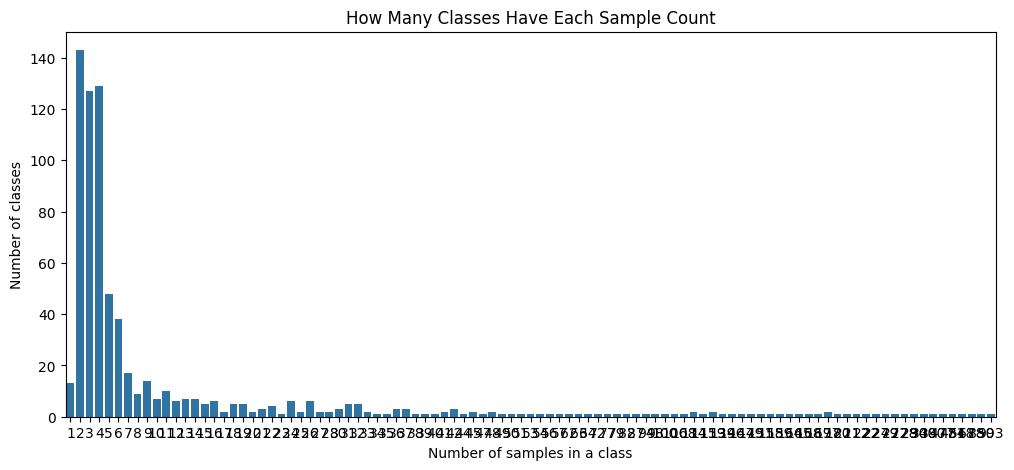

In [5]:

count_of_counts = df["label"].value_counts().value_counts().sort_index()

count_summary_df = pd.DataFrame({
    "samples_in_class": count_of_counts.index,
    "number_of_classes": count_of_counts.values
}).sort_values("samples_in_class")

display(count_summary_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=count_summary_df, x="samples_in_class", y="number_of_classes")
plt.title("How Many Classes Have Each Sample Count")
plt.xlabel("Number of samples in a class")
plt.ylabel("Number of classes")
plt.show()

In [7]:
class_counts = df["label"].value_counts()

classes_above = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS]
print(f"Number of classes remaining from min samples {MIN_SAMPLES_PER_CLASS} samples:", len(classes_above))


Number of classes remaining from min samples 0 samples: 718


In [11]:

class_counts = df["label"].value_counts()

valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
removed_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()

df_filtered = df[df["label"].isin(valid_classes)].reset_index(drop=True)

print(f"MIN_SAMPLES_PER_CLASS = {MIN_SAMPLES_PER_CLASS}")
print("Classes kept   :", len(valid_classes))
print("Classes removed:", len(removed_classes))
print("Images before  :", len(df))
print("Images after   :", len(df_filtered))

print("\nRemoved classes and their counts:")
display(class_counts[class_counts < MIN_SAMPLES_PER_CLASS].sort_values())

print("\nKept class distribution:")
display(df_filtered["label"].value_counts().sort_values(ascending=False).head(20))

MIN_SAMPLES_PER_CLASS = 0
Classes kept   : 718
Classes removed: 0
Images before  : 15847
Images after   : 15847

Removed classes and their counts:


Series([], Name: count, dtype: int64)


Kept class distribution:


label
N35    993
M17    850
X1     678
D21    548
S29    481
I9     477
G43    380
G17    340
V30    290
D4     278
V31    272
R8     249
D36    227
Q3     222
V28    212
M23    211
N33    180
F35    177
Q1     177
A1     169
Name: count, dtype: int64

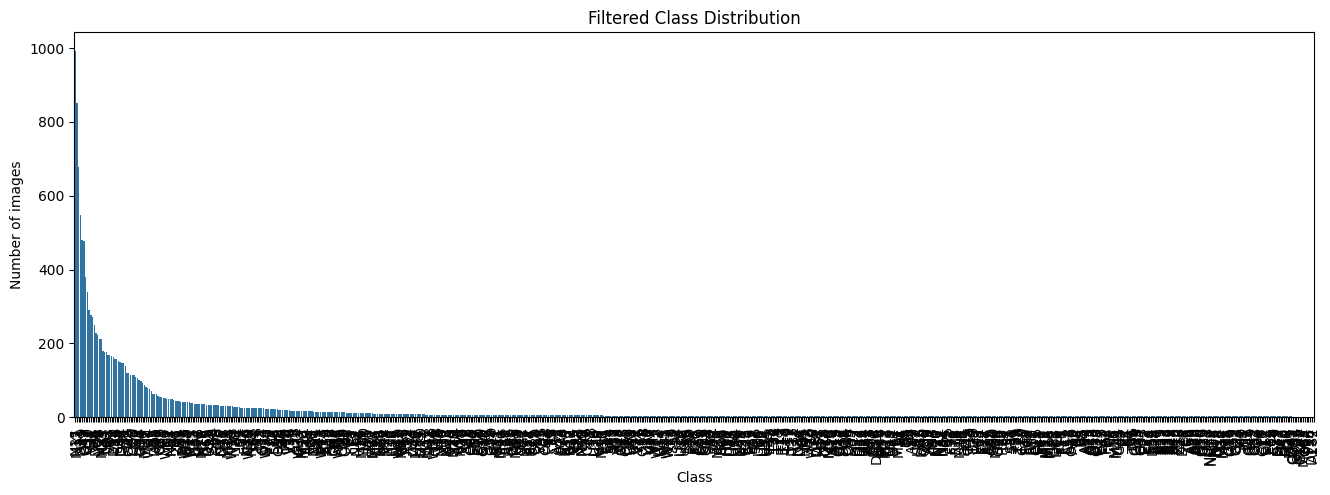

count    718.000000
mean      22.071031
std       74.310324
min        1.000000
25%        3.000000
50%        4.000000
75%        9.750000
max      993.000000
Name: count, dtype: float64


In [12]:

filtered_counts = df_filtered["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
sns.barplot(x=filtered_counts.index.astype(str), y=filtered_counts.values)
plt.title("Filtered Class Distribution")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.show()

print(filtered_counts.describe())

## Label encoding

In [13]:


class_names = sorted(df_filtered["label"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df_filtered["label_idx"] = df_filtered["label"].map(class_to_idx)

NUM_CLASSES = len(class_names)

print("Number of classes after filtering:", NUM_CLASSES)
display(df_filtered.head())

Number of classes after filtering: 718


,filepath,label,label_idx
0,/kaggle/input/datasets/malakdiab04/final-class...,A1,0
1,/kaggle/input/datasets/malakdiab04/final-class...,A1,0
2,/kaggle/input/datasets/malakdiab04/final-class...,A1,0
3,/kaggle/input/datasets/malakdiab04/final-class...,A1,0
4,/kaggle/input/datasets/malakdiab04/final-class...,A1,0


In [16]:

def custom_split(df_filtered, seed=42):

    train_rows = []
    val_rows = []
    test_rows = []

    for label, group in df_filtered.groupby("label"):

        group = group.sample(frac=1.0, random_state=seed).reset_index(drop=True)

        n = len(group)

        if n == 1:

            train_rows.append(group)

        elif n == 2:

            train_rows.append(group.iloc[:1])
            val_rows.append(group.iloc[1:2])

        elif n == 3:

            train_rows.append(group.iloc[:1])
            val_rows.append(group.iloc[1:2])
            test_rows.append(group.iloc[2:3])

        else:

            train_group, temp_group = train_test_split(
                group,
                test_size=0.30,
                random_state=seed,
                shuffle=True
            )

            val_group, test_group = train_test_split(
                temp_group,
                test_size=0.50,
                random_state=seed,
                shuffle=True
            )

            train_rows.append(train_group)
            val_rows.append(val_group)
            test_rows.append(test_group)

    train_df = pd.concat(train_rows, ignore_index=True)

    val_df = (
        pd.concat(val_rows, ignore_index=True)
        if len(val_rows) > 0
        else pd.DataFrame(columns=df_filtered.columns)
    )

    test_df = (
        pd.concat(test_rows, ignore_index=True)
        if len(test_rows) > 0
        else pd.DataFrame(columns=df_filtered.columns)
    )

    train_df = train_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    if len(val_df) > 0:
        val_df = val_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    if len(test_df) > 0:
        test_df = test_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    print("Train samples:", len(train_df))
    print("Val samples  :", len(val_df))
    print("Test samples :", len(test_df))

    print()

    print("Train classes:", train_df["label"].nunique())
    print("Val classes  :", val_df["label"].nunique())
    print("Test classes :", test_df["label"].nunique())

    return train_df, val_df, test_df

In [17]:

class_names = sorted(df_filtered["label"].unique())

class_to_idx = {
    cls: idx
    for idx, cls in enumerate(class_names)
}

NUM_CLASSES = len(class_names)

print("Total classes:", NUM_CLASSES)

Total classes: 718


In [18]:
train_df, val_df, test_df = custom_split(df_filtered, seed=SEED)

Train samples: 10657
Val samples  : 2608
Test samples : 2582

Train classes: 718
Val classes  : 705
Test classes : 562


In [19]:
train_df["label_idx"] = train_df["label"].map(class_to_idx)
val_df["label_idx"] = val_df["label"].map(class_to_idx)
test_df["label_idx"] = test_df["label"].map(class_to_idx)

In [20]:
print("Unique classes in train_df:", train_df["label"].nunique())

Unique classes in train_df: 718


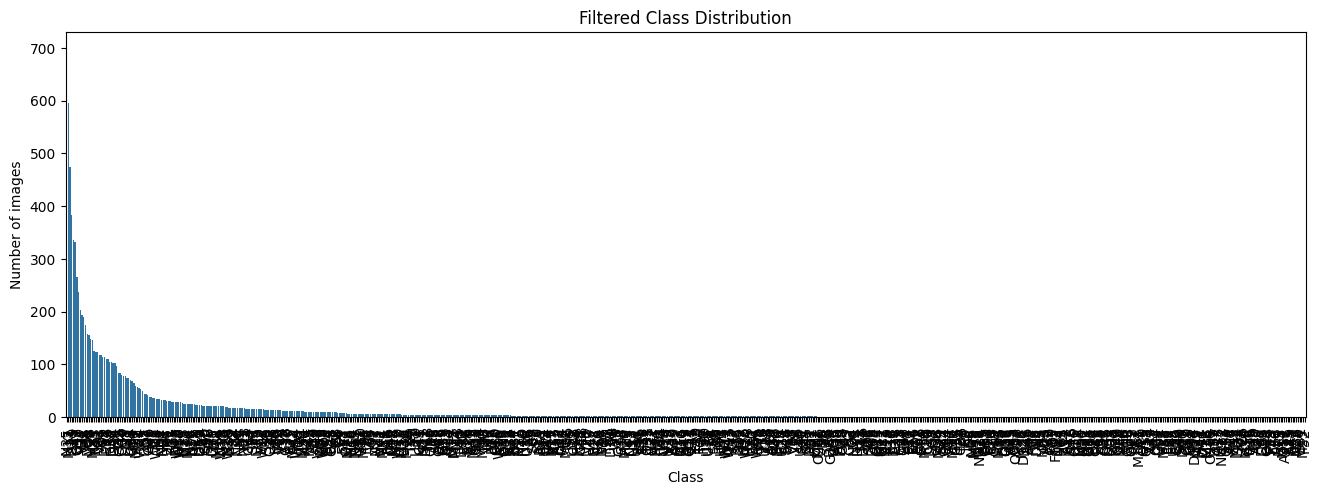

count    718.000000
mean      14.842618
std       52.061347
min        1.000000
25%        1.000000
50%        2.000000
75%        6.750000
max      695.000000
Name: count, dtype: float64


In [21]:

filtered_counts = train_df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
sns.barplot(x=filtered_counts.index.astype(str), y=filtered_counts.values)
plt.title("Filtered Class Distribution")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.show()

print(filtered_counts.describe())

In [24]:

OUTPUT_AUG_DIR = "/kaggle/working/augmented"
os.makedirs(OUTPUT_AUG_DIR, exist_ok=True)

def augment_image(img):
    img = img.convert("RGB")

    ops = [
        lambda x: ImageOps.mirror(x),
        lambda x: x.rotate(random.uniform(-8, 8)),
        lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.7, 1.3)),
        lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.7, 1.3)),
    ]

    '''op = random.choice(ops)
    img = op(img)'''
    if random.random() < 0.70:
        op = random.choice(ops)
        img = op(img)

    if random.random() < 0.3:
        img = img.rotate(
            random.uniform(-5, 5),
            resample=Image.BICUBIC,
            expand=True,
            fillcolor=(255, 255, 255)
        )

    if random.random() < 0.12:
        arr = np.array(img).astype(np.float32)
        h, w, _ = arr.shape

        base_color = np.array([
            random.randint(185, 220),
            random.randint(165, 205),
            random.randint(120, 170)
        ])

        noise = np.random.normal(0, random.uniform(4, 12), size=(h, w, 1))
        texture = base_color.reshape(1, 1, 3) + noise
        texture = np.clip(texture, 0, 255)

        gray = np.array(img.convert("L"))
        symbol_mask = (gray < 210)[..., None]

        glyph_color = np.array([
            random.randint(60, 110),
            random.randint(45, 90),
            random.randint(35, 80)
        ], dtype=np.float32).reshape(1, 1, 3)

        out = np.where(symbol_mask, glyph_color, texture)

        alpha = random.uniform(0.65, 0.90)
        out = alpha * out + (1 - alpha) * arr

        img = Image.fromarray(np.clip(out, 0, 255).astype(np.uint8))

    if random.random() < 0.75:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.2))

    if random.random() < 0.75:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.90, 1.12))

    if random.random() < 0.10:
        arr = np.array(img).astype(np.float32)
        h, w, _ = arr.shape

        if random.random() < 0.5:
            gradient = np.linspace(0.92, 1.08, w)[None, :, None]
        else:
            gradient = np.linspace(0.85, 1.15, h)[:, None, None]

        arr = arr * gradient
        img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

    if random.random() < 0.18:
        if random.random() < 0.6:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.6)))

        arr = np.array(img).astype(np.float32)

        if random.random() < 0.7:
            noise = np.random.normal(0, random.uniform(1, 4), arr.shape)
            arr = arr + noise

        img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

    gray = np.array(img.convert("L"))
    mask = gray < 248
    coords = np.column_stack(np.where(mask))

    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        padding = 6
        x_min = max(0, x_min - padding)
        y_min = max(0, y_min - padding)
        x_max = min(img.size[0] - 1, x_max + padding)
        y_max = min(img.size[1] - 1, y_max + padding)

        img = img.crop((x_min, y_min, x_max + 1, y_max + 1))

    img = ImageOps.pad(
        img,
        (224, 224),
        method=Image.BICUBIC,
        color=(255, 255, 255),
        centering=(0.5, 0.5)
    )

    return img

In [25]:
def augment_to_range(df_in, min_target=35, max_target=220):
    new_records = []
    dfs = []

    class_counts = df_in["label"].value_counts()

    q25 = class_counts.quantile(0.25)
    q75 = class_counts.quantile(0.75)
    q90 = class_counts.quantile(0.90)

    print(f"Q25={q25:.2f}, Q75={q75:.2f}, Q90={q90:.2f}")

    for label, group in df_in.groupby("label"):
        n = len(group)

        if n <= q25:
            target_size = min_target
            category = "RARE"

        elif n <= q75:
            target_size = random.randint(int(0.6 * max_target), max_target)
            category = "MID"

        elif n <= q90:
            target_size = int(0.85 * max_target)
            category = "LARGE"

        else:
            target_size = max_target
            category = "VERY LARGE"

        target_size = min(target_size, max_target)

        if target_size > n:
            needed = target_size - n
            print(f"[{category} - AUG] {label}: {n} → {target_size}")

            for _ in range(needed):
                row = group.sample(n=1, replace=True).iloc[0]

                try:
                    img = Image.open(row["filepath"]).convert("RGB")
                    aug_img = augment_image(img)

                    new_filename = f"{label}_{uuid.uuid4().hex}.png"
                    new_path = os.path.join(OUTPUT_AUG_DIR, new_filename)

                    aug_img.save(new_path)
                    new_records.append((new_path, label))

                except Exception as e:
                    print(f"Error: {e}")

            dfs.append(group)

        elif target_size < n:
            print(f"[{category} - DOWN] {label}: {n} → {target_size}")
            group = group.sample(n=target_size, random_state=SEED)
            dfs.append(group)

        else:
            print(f"[{category} - KEEP] {label}: {n}")
            dfs.append(group)

    df_aug = pd.DataFrame(new_records, columns=["filepath", "label"])
    df_out = pd.concat(dfs + [df_aug], ignore_index=True)

    df_out = df_out.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    return df_out

In [26]:
train_df_balanced = augment_to_range(train_df, 35, 220)

train_df_balanced["label_idx"] = train_df_balanced["label"].map(class_to_idx)

print("\nTrain class counts (AFTER balancing):")
display(train_df_balanced["label"].value_counts().sort_values())

counts = train_df_balanced["label"].value_counts()

print("Min samples:", counts.min())
print("Max samples:", counts.max())
print(counts.describe())

Q25=1.00, Q75=6.75, Q90=25.00
[VERY LARGE - AUG] A1: 118 → 220
[RARE - AUG] A10: 1 → 35
[RARE - AUG] A11: 1 → 35
[RARE - AUG] A12: 1 → 35
[RARE - AUG] A13: 1 → 35
[MID - AUG] A14: 3 → 144
[MID - AUG] A15: 4 → 202
[MID - AUG] A16: 2 → 183
[MID - AUG] A17: 6 → 181
[RARE - AUG] A18: 1 → 35
[LARGE - AUG] A19: 9 → 187
[LARGE - AUG] A2: 25 → 187
[RARE - AUG] A20: 1 → 35
[RARE - AUG] A21: 1 → 35
[RARE - AUG] A22: 1 → 35
[RARE - AUG] A23: 1 → 35
[LARGE - AUG] A24: 10 → 187
[RARE - AUG] A25: 1 → 35
[MID - AUG] A26: 4 → 191
[RARE - AUG] A27: 1 → 35
[MID - AUG] A28: 4 → 165
[RARE - AUG] A282: 1 → 35
[RARE - AUG] A29: 1 → 35
[MID - AUG] A3: 2 → 138
[LARGE - AUG] A30: 12 → 187
[RARE - AUG] A31: 1 → 35
[RARE - AUG] A32: 1 → 35
[RARE - AUG] A33: 1 → 35
[RARE - AUG] A34: 1 → 35
[RARE - AUG] A35: 1 → 35
[RARE - AUG] A36: 1 → 35
[RARE - AUG] A37: 1 → 35
[RARE - AUG] A38: 1 → 35
[MID - AUG] A4: 2 → 145
[VERY LARGE - AUG] A40: 39 → 220
[RARE - AUG] A41: 1 → 35
[LARGE - AUG] A42: 11 → 187
[RARE - AUG] A43:

label
F38     35
D33     35
G16     35
S31     35
D53     35
      ... 
N25    220
S21    220
G36    220
N14    220
S7     220
Name: count, Length: 718, dtype: int64

Min samples: 35
Max samples: 220
count    718.000000
mean     126.516713
std       76.274931
min       35.000000
25%       35.000000
50%      161.000000
75%      187.000000
max      220.000000
Name: count, dtype: float64


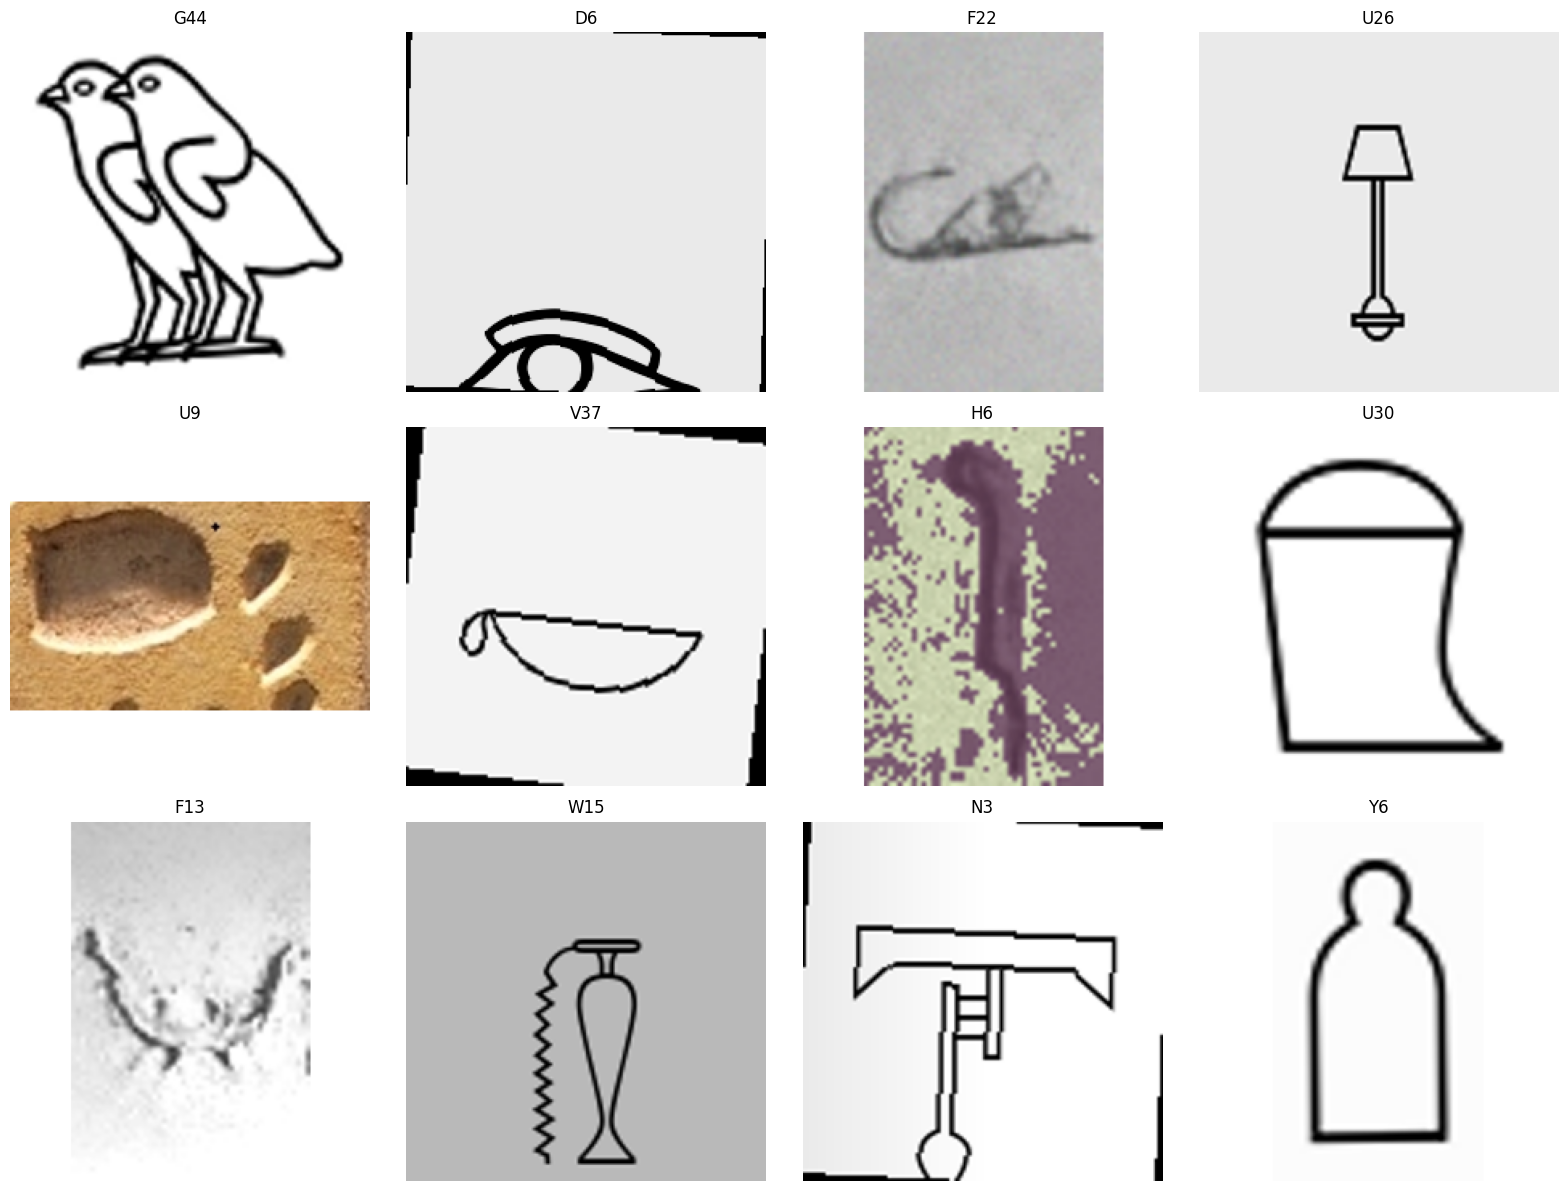

In [29]:

def show_samples(df_subset, n=12, cols=4):
    sample_df = df_subset.sample(min(n, len(df_subset)), random_state=SEED)
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        plt.subplot(rows, cols, i)
        img = Image.open(row["filepath"]).convert("RGB")
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_df_balanced, n=12, cols=4)

In [31]:
train_paths = train_df_balanced["filepath"].values
train_labels = train_df_balanced["label_idx"].values

val_paths = val_df["filepath"].values
val_labels = val_df["label_idx"].values

test_paths = test_df["filepath"].values
test_labels = test_df["label_idx"].values

NUM_CLASSES = len(class_names)

def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=CHANNELS, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.int32)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.03,0.03),
    layers.RandomContrast(0.20),
    layers.RandomBrightness(0.10),
], name="augmentation")

def mixup(images, labels, alpha=0.3):
    images = tf.cast(images, tf.float32)
    labels = tf.cast(labels, tf.float32)

    batch_size = tf.shape(images)[0]

    lam = tf.random.uniform([], 0, 1)
    lam = tf.maximum(lam, 1 - lam)

    idx = tf.random.shuffle(tf.range(batch_size))

    mixed_images = lam * images + (1 - lam) * tf.gather(images, idx)
    mixed_labels = lam * labels + (1 - lam) * tf.gather(labels, idx)

    return mixed_images, mixed_labels

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    ds = ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)),
                num_parallel_calls=AUTOTUNE)

    if training and USE_AUGMENTATION:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)

    if training and USE_MIXUP:
        ds = ds.map(lambda x, y: mixup(x, y, alpha=0.3),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)

print(train_ds)

I0000 00:00:1778229232.595937      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778229232.599020      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 718), dtype=tf.float32, name=None))>


In [32]:
print("Unique labels in TRAIN:", len(np.unique(train_labels)))
print("Unique labels in VAL  :", len(np.unique(val_labels)))
print("Unique labels in TEST :", len(np.unique(test_labels)))

Unique labels in TRAIN: 718
Unique labels in VAL  : 705
Unique labels in TEST : 562


In [33]:
missing = set(range(NUM_CLASSES)) - set(np.unique(train_labels))
print("Missing classes in train:", len(missing))

Missing classes in train: 0


In [34]:
def get_preprocess_and_backbone(model_name, img_size):
    model_name = model_name.lower()

    if model_name == "efficientnetv2b0":
        preprocess = tf.keras.applications.efficientnet_v2.preprocess_input
        backbone = tf.keras.applications.EfficientNetV2B0(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 1280

    elif model_name == "efficientnetv2s":
        preprocess = tf.keras.applications.efficientnet_v2.preprocess_input
        backbone = tf.keras.applications.EfficientNetV2S(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 1280

    elif model_name == "resnet101v2":
        preprocess = tf.keras.applications.resnet_v2.preprocess_input
        backbone = tf.keras.applications.ResNet101V2(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 2048

    elif model_name == "densenet121":
        preprocess = tf.keras.applications.densenet.preprocess_input
        backbone = tf.keras.applications.DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=(img_size, img_size, 3)
        )
        feature_dim = 1024

    else:
        raise ValueError(f"Unsupported transfer model: {model_name}")

    return preprocess, backbone, feature_dim

In [36]:
def build_model(model_name, num_classes, img_size=224):
    model_name = model_name.lower()
    preprocess, backbone, feature_dim = get_preprocess_and_backbone(model_name, img_size)
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = preprocess(inputs)
    x = backbone(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense( 512, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4) )(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax",dtype="float32")(x)
    model = keras.Model(inputs, outputs, name=model_name)
    return model, backbone

In [37]:
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled.")
except Exception as e:
    print("Could not enable mixed precision:", e)

def get_callbacks(run_name):
    ckpt_path = os.path.join(OUTPUT_DIR, f"{run_name}_best.keras")

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path,
            monitor="val_categorical_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_categorical_accuracy",
            patience=5,
            mode="max",
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            os.path.join(OUTPUT_DIR, f"{run_name}_training_log.csv")
        )
    ]
    return callbacks

if USE_CLASS_WEIGHTS:
    classes_for_weights = np.unique(train_labels)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes_for_weights,
        y=train_labels
    )
    class_weight_dict = {int(c): float(w) for c, w in zip(classes_for_weights, weights)}
else:
    class_weight_dict = None

print("Class weights:", class_weight_dict if class_weight_dict else "Not used")

Mixed precision enabled.
Class weights: Not used


In [ ]:
def compile_model(model, lr):
    optimizer = keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(),
        metrics=[
            keras.metrics.CategoricalAccuracy(name="categorical_accuracy")
        ]
    )

def plot_history(history, title="Training History"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["categorical_accuracy"], label="train_acc")
    plt.plot(hist["val_categorical_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()

def train_model(model_name, train_ds, val_ds, num_classes, img_size):
    run_name = f"{model_name}_img{img_size}"
    print(f"\n========== TRAINING: {run_name} ==========\n")

    model, backbone = build_model(model_name, num_classes, img_size)

    print(model.summary())

    if backbone is not None:
        backbone.trainable = False
        compile_model(model, LEARNING_RATE_HEAD)

        history_head = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_HEAD,
            callbacks=get_callbacks(run_name + "_head"),
            class_weight=class_weight_dict,
            verbose=1
        )

        plot_history(history_head, title=f"{run_name} - Head Training")
        print("\nFinal Head Training Metrics:")
        print("Train Loss:", history_head.history["loss"][-1])
        print("Train Acc :", history_head.history["categorical_accuracy"][-1])
        print("Val Loss  :", history_head.history["val_loss"][-1])
        print("Val Acc   :", history_head.history["val_categorical_accuracy"][-1])

        backbone.trainable = True
        unfreeze_from = int(len(backbone.layers) * 0.6)
        for layer in backbone.layers[:unfreeze_from]:
            layer.trainable = False

        for layer in backbone.layers[unfreeze_from:]:
            layer.trainable = True


        compile_model(model, LEARNING_RATE_FINE)

        history_fine = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS_FINE,
            callbacks=get_callbacks(run_name + "_fine"),
            class_weight=class_weight_dict,
            verbose=1
        )

        plot_history(history_fine, title=f"{run_name} - Fine Tuning")
        print("\nFinal Fine-Tuning Metrics:")
        print("Train Loss:", history_fine.history["loss"][-1])
        print("Train Acc :", history_fine.history["categorical_accuracy"][-1])
        print("Val Loss  :", history_fine.history["val_loss"][-1])
        print("Val Acc   :", history_fine.history["val_categorical_accuracy"][-1])

        print("\nBest Validation Metrics:")
        print("Best Val Acc :", max(history_fine.history["val_categorical_accuracy"]))
        print("Best Val Loss:", min(history_fine.history["val_loss"]))



    return model


========== TRAINING: efficientnetv2b0_img224 ==========



Model: "efficientnetv2b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 718)            │       368,334 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,948,638 (26.51 MB)

 Trainable params: 6,885,470 (26.27 MB)

 Non-trainable params: 63,168 (246.75 KB)

None
Epoch 1/20
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - categorical_accuracy: 0.2088 - loss: 5.0230
Epoch 1: val_categorical_accuracy improved from -inf to 0.47431, saving model to /kaggle/working/efficientnetv2b0_img224_head_best.keras
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 662s 221ms/step - categorical_accuracy: 0.2088 - loss: 5.0228 - val_categorical_accuracy: 0.4743 - val_loss: 2.6379 - learning_rate: 0.0010
Epoch 2/20
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - categorical_accuracy: 0.4082 - loss: 3.8133
Epoch 2: val_categorical_accuracy improved from 0.47431 to 0.51687, saving model to /kaggle/working/efficientnetv2b0_img224_head_best.keras
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 580s 205ms/step - categorical_accuracy: 0.4082 - loss: 3.8133 - val_categorical_accuracy: 0.5169 - val_loss: 2.4342 - learning_rate: 0.0010
Epoch 3/20
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - categorical_accuracy: 0.4411 - loss: 3.7009
Epoch 3: val_categorical_accuracy improved from 0.51687 to 0.54026, sa

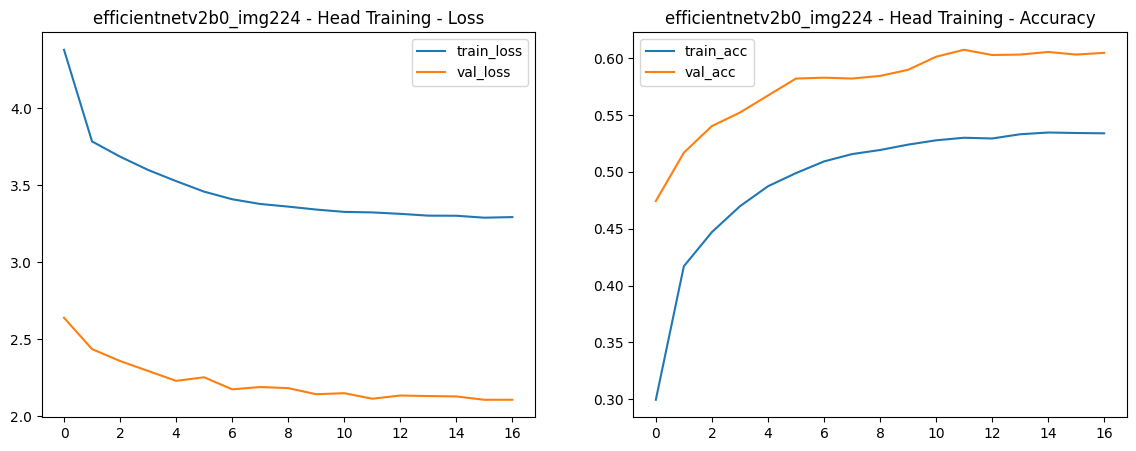


Final Head Training Metrics:
Train Loss: 3.291834592819214
Train Acc : 0.5338937044143677
Val Loss  : 2.1051716804504395
Val Acc   : 0.6046779155731201
Epoch 1/35
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - categorical_accuracy: 0.5031 - loss: 3.4951
Epoch 1: val_categorical_accuracy improved from -inf to 0.65337, saving model to /kaggle/working/efficientnetv2b0_img224_fine_best.keras
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 757s 241ms/step - categorical_accuracy: 0.5032 - loss: 3.4950 - val_categorical_accuracy: 0.6534 - val_loss: 1.8685 - learning_rate: 2.0000e-05
Epoch 2/35
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - categorical_accuracy: 0.6176 - loss: 2.9867
Epoch 2: val_categorical_accuracy improved from 0.65337 to 0.67485, saving model to /kaggle/working/efficientnetv2b0_img224_fine_best.keras
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 603s 213ms/step - categorical_accuracy: 0.6176 - loss: 2.9867 - val_categorical_accuracy: 0.6748 - val_loss: 1.7281 - learning_rate: 2.0000e-05
Epoch 3/35
2833/

In [ ]:
model = train_model(
    model_name=MODEL_NAME,
    train_ds=train_ds,
    val_ds=val_ds,
    num_classes=NUM_CLASSES,
    img_size=IMG_SIZE
)

In [49]:

checkpoint_path = "/kaggle/working/efficientnetv2b0_img224_fine_best.keras"

model = keras.models.load_model(checkpoint_path)
LEARNING_RATE_FINE = 2e-5
compile_model(model, LEARNING_RATE_FINE)

In [ ]:
history_resume = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=25,
    epochs=35,
    callbacks=get_callbacks("resume_fine"),
    verbose=1
)

Epoch 26/35
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - categorical_accuracy: 0.7553 - loss: 2.0139
Epoch 26: val_categorical_accuracy improved from -inf to 0.79640, saving model to /kaggle/working/resume_fine_best.keras
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 603s 213ms/step - categorical_accuracy: 0.7553 - loss: 2.0139 - val_categorical_accuracy: 0.7964 - val_loss: 1.1487 - learning_rate: 2.0000e-05
Epoch 27/35
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - categorical_accuracy: 0.7526 - loss: 2.0123
Epoch 27: val_categorical_accuracy improved from 0.79640 to 0.80061, saving model to /kaggle/working/resume_fine_best.keras
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 616s 217ms/step - categorical_accuracy: 0.7526 - loss: 2.0123 - val_categorical_accuracy: 0.8006 - val_loss: 1.1279 - learning_rate: 2.0000e-05
Epoch 28/35
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - categorical_accuracy: 0.7560 - loss: 1.9781
Epoch 28: val_categorical_accuracy improved from 0.80061 to 0.80368, saving model to /kaggle/wor

In [39]:
checkpoint_path = "/kaggle/input/models/amelsidkey/resume-fine-best/keras/default/1/resume_fine_best.keras"

model = keras.models.load_model(checkpoint_path)
LEARNING_RATE_FINE = 2e-5
compile_model(model, LEARNING_RATE_FINE)

In [40]:
history_resume = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=32,
    epochs=35,
    callbacks=get_callbacks("final_resume_fine"),
    verbose=1
)

Epoch 33/35


I0000 00:00:1778229450.268800     131 service.cc:152] XLA service 0x7d464c01d630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778229450.268854     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778229450.268859     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778229458.474002     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778229499.812007     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2839/2839 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - categorical_accuracy: 0.7581 - loss: 1.9439
Epoch 33: val_categorical_accuracy improved from -inf to 0.80560, saving model to /kaggle/working/final_resume_fine_best.keras
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 843s 262ms/step - categorical_accuracy: 0.7581 - loss: 1.9439 - val_categorical_accuracy: 0.8056 - val_loss: 1.1175 - learning_rate: 2.0000e-05
Epoch 34/35
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - categorical_accuracy: 0.7593 - loss: 1.9360
Epoch 34: val_categorical_accuracy improved from 0.80560 to 0.80752, saving model to /kaggle/working/final_resume_fine_best.keras
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 629s 222ms/step - categorical_accuracy: 0.7593 - loss: 1.9360 - val_categorical_accuracy: 0.8075 - val_loss: 1.1150 - learning_rate: 2.0000e-05
Epoch 35/35
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - categorical_accuracy: 0.7594 - loss: 1.9199
Epoch 35: val_categorical_accuracy improved from 0.80752 to 0.81135, saving model to /kaggle/wor

In [42]:
final_train_acc = history_resume.history["categorical_accuracy"][-1]
final_train_loss = history_resume.history["loss"][-1]
best_val_acc = max(history_resume.history["val_categorical_accuracy"])
best_val_loss = min(history_resume.history["val_loss"])

print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Train Loss    : {final_train_loss:.4f}")
print("-" * 30)
print(f"Best Val Accuracy   : {best_val_acc:.4f}")
print(f"Best Val Loss       : {best_val_loss:.4f}")

Final Train Accuracy: 0.7588
Final Train Loss    : 1.9217
------------------------------
Best Val Accuracy   : 0.8113
Best Val Loss       : 1.0927


In [43]:
def predict_dataset(model, ds):
    probs = model.predict(ds, verbose=1)
    preds = np.argmax(probs, axis=1)
    return probs, preds

test_probs, test_preds = predict_dataset(model, test_ds)

test_true = test_labels

test_acc = accuracy_score(test_true, test_preds)
test_f1_macro = f1_score(test_true, test_preds, average="macro")
test_bal_acc = balanced_accuracy_score(test_true, test_preds)

print(f"Test Accuracy         : {test_acc:.4f}")
print(f"Test Macro F1         : {test_f1_macro:.4f}")
print(f"Test Balanced Accuracy: {test_bal_acc:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
Test Accuracy         : 0.8288
Test Macro F1         : 0.6164
Test Balanced Accuracy: 0.6652


Loaded best model from: /kaggle/working/final_resume_fine_best.keras
Recompiled with LR = 1e-05
Epoch 1/25
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - categorical_accuracy: 0.7589 - loss: 1.9092
Epoch 1: val_categorical_accuracy improved from -inf to 0.80982, saving model to /kaggle/working/stage3_lowlr_best.keras
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 783s 248ms/step - categorical_accuracy: 0.7589 - loss: 1.9092 - val_categorical_accuracy: 0.8098 - val_loss: 1.0956 - learning_rate: 1.0000e-05
Epoch 2/25
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - categorical_accuracy: 0.7620 - loss: 1.8985
Epoch 2: val_categorical_accuracy improved from 0.80982 to 0.81327, saving model to /kaggle/working/stage3_lowlr_best.keras
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 637s 224ms/step - categorical_accuracy: 0.7620 - loss: 1.8985 - val_categorical_accuracy: 0.8133 - val_loss: 1.0874 - learning_rate: 1.0000e-05
Epoch 3/25
2839/2839 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - categorical_accuracy: 0.7623 - loss: 1.8881
Epo

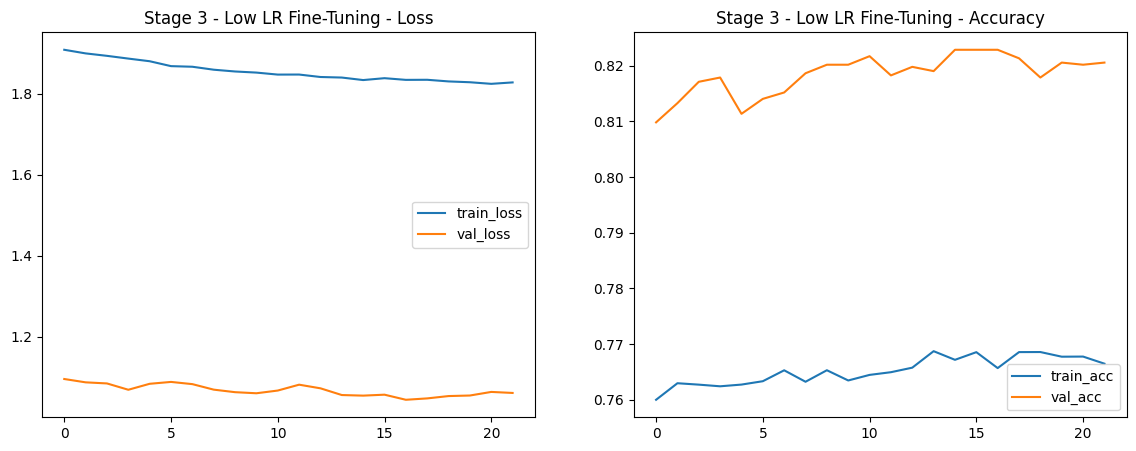


STAGE 3 RESULTS
Final Train Accuracy: 0.7665
Final Train Loss    : 1.8274
------------------------------
Best Val Accuracy   : 0.8229
Best Val Loss       : 1.0443
Stage 3 best model loaded from: /kaggle/working/stage3_lowlr_best.keras


In [48]:

best_model_path = "/kaggle/working/final_resume_fine_best.keras"
model = keras.models.load_model(best_model_path)
print("Loaded best model from:", best_model_path)


LEARNING_RATE_STAGE3 = 1e-5

for layer in model.layers[-40:]:
    layer.trainable = True

compile_model(model, LEARNING_RATE_STAGE3)
print(f"Recompiled with LR = {LEARNING_RATE_STAGE3}")

def get_callbacks_stage3(run_name):
    ckpt_path = os.path.join(OUTPUT_DIR, f"{run_name}_best.keras")
    return [
        keras.callbacks.ModelCheckpoint(
            ckpt_path,
            monitor="val_categorical_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_categorical_accuracy",
            patience=7,
            mode="max",
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            os.path.join(OUTPUT_DIR, f"{run_name}_log.csv")
        )
    ]

history_stage3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=get_callbacks_stage3("stage3_lowlr"),
    class_weight=class_weight_dict,
    verbose=1
)

plot_history(history_stage3, title="Stage 3 - Low LR Fine-Tuning")

print("\n" + "="*30)
print("STAGE 3 RESULTS")
print("="*30)

final_train_acc = history_stage3.history["categorical_accuracy"][-1]
final_train_loss = history_stage3.history["loss"][-1]
best_val_acc = max(history_stage3.history["val_categorical_accuracy"])
best_val_loss = min(history_stage3.history["val_loss"])

print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Train Loss    : {final_train_loss:.4f}")
print("-" * 30)
print(f"Best Val Accuracy   : {best_val_acc:.4f}")
print(f"Best Val Loss       : {best_val_loss:.4f}")
print("="*30)

best_stage3_path = "/kaggle/working/stage3_lowlr_best.keras"
model_stage3 = keras.models.load_model(best_stage3_path)
print("Stage 3 best model loaded from:", best_stage3_path)


In [49]:
def predict_dataset(model, ds):
    probs = model.predict(ds, verbose=1)
    preds = np.argmax(probs, axis=1)
    return probs, preds

test_probs, test_preds = predict_dataset(model, test_ds)

test_true = test_labels

test_acc = accuracy_score(test_true, test_preds)
test_f1_macro = f1_score(test_true, test_preds, average="macro")
test_bal_acc = balanced_accuracy_score(test_true, test_preds)

print(f"Test Accuracy         : {test_acc:.4f}")
print(f"Test Macro F1         : {test_f1_macro:.4f}")
print(f"Test Balanced Accuracy: {test_bal_acc:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 254ms/step
Test Accuracy         : 0.8369
Test Macro F1         : 0.6280
Test Balanced Accuracy: 0.6737


In [57]:
test_labels_present = np.unique(test_true)

test_class_names = [class_names[i] for i in test_labels_present]

report = classification_report(
    test_true,
    test_preds,
    labels=test_labels_present,
    target_names=test_class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

          A1     0.8800    0.8462    0.8627        26
         A12     0.0000    0.0000    0.0000         1
         A14     1.0000    1.0000    1.0000         1
         A15     1.0000    1.0000    1.0000         1
         A16     0.0000    0.0000    0.0000         1
         A17     1.0000    1.0000    1.0000         2
         A19     0.6667    0.6667    0.6667         3
          A2     0.5000    0.5000    0.5000         6
         A20     0.0000    0.0000    0.0000         1
         A21     0.0000    0.0000    0.0000         1
         A24     0.5000    0.3333    0.4000         3
         A26     0.0000    0.0000    0.0000         1
         A28     0.0000    0.0000    0.0000         2
          A3     0.0000    0.0000    0.0000         1
         A30     1.0000    0.6667    0.8000         3
         A34     0.5000    1.0000    0.6667         1
         A35     0.0000    0.0000    0.0000         1
         A38     1.0000    

In [58]:
report = classification_report(
    test_true,
    test_preds,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.8800    0.8462    0.8627        26
           2     0.0000    0.0000    0.0000         0
           3     0.0000    0.0000    0.0000         1
           5     1.0000    1.0000    1.0000         1
           6     1.0000    1.0000    1.0000         1
           7     0.0000    0.0000    0.0000         1
           8     1.0000    1.0000    1.0000         2
          10     0.6667    0.6667    0.6667         3
          11     0.5000    0.5000    0.5000         6
          12     0.0000    0.0000    0.0000         1
          13     0.0000    0.0000    0.0000         1
          15     0.0000    0.0000    0.0000         0
          16     0.5000    0.3333    0.4000         3
          17     0.0000    0.0000    0.0000         0
          18     0.0000    0.0000    0.0000         1
          20     0.0000    0.0000    0.0000         2
          23     0.0000    0.0000    0.0000         1
          24     1.0000    

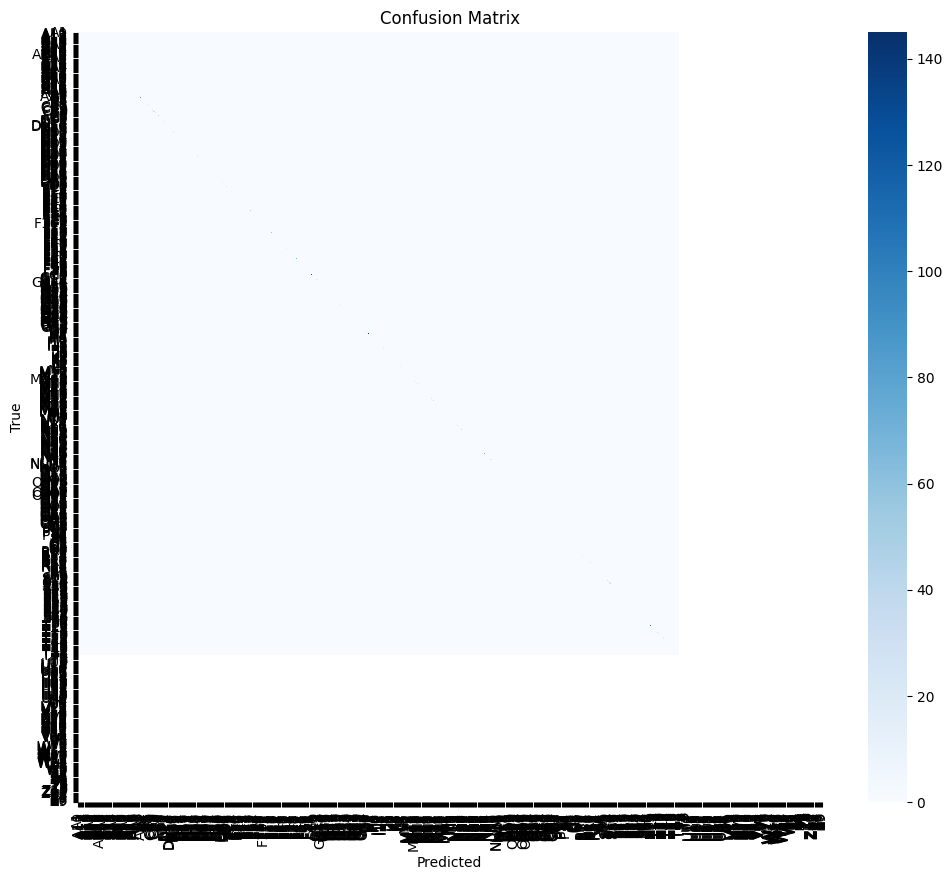

In [59]:
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Wrong predictions: 421


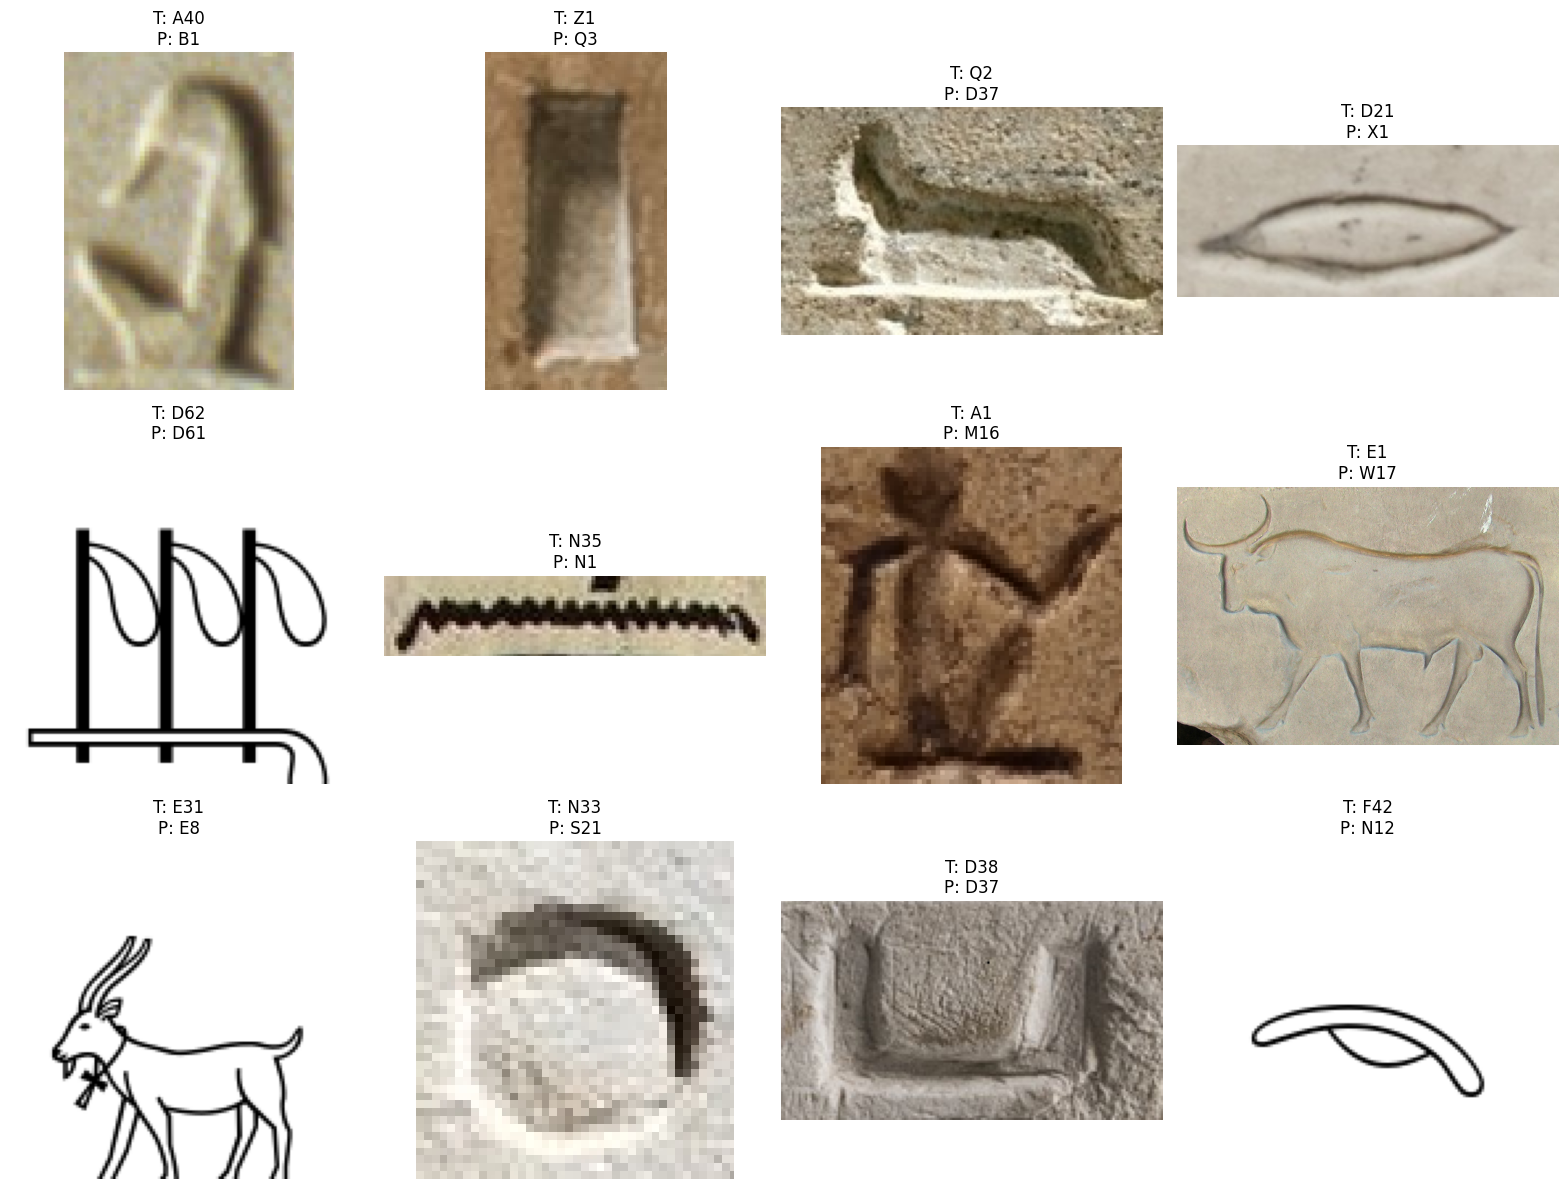

In [60]:
test_results_df = test_df.copy()
test_results_df["pred_idx"] = test_preds
test_results_df["pred_label"] = test_results_df["pred_idx"].map(idx_to_class)
test_results_df["correct"] = test_results_df["label"] == test_results_df["pred_label"]

wrong_df = test_results_df[~test_results_df["correct"]].copy()
print("Wrong predictions:", len(wrong_df))

def show_wrong_predictions(df_wrong, n=12, cols=4):
    if len(df_wrong) == 0:
        print("No wrong predictions to display.")
        return

    sample_df = df_wrong.sample(min(n, len(df_wrong)), random_state=SEED)
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        plt.subplot(rows, cols, i)
        img = Image.open(row["filepath"]).convert("RGB")
        plt.imshow(img)
        plt.title(f"T: {row['label']}\nP: {row['pred_label']}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_wrong_predictions(wrong_df, n=12, cols=4)

In [62]:
def load_and_prepare_image(image_path, img_size=224):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((img_size, img_size))
    arr = np.array(img).astype(np.float32)
    arr = np.expand_dims(arr, axis=0)
    return img, arr

def predict_single_image(model, image_path, idx_to_class, img_size=224, top_k=5):
    pil_img, arr = load_and_prepare_image(image_path, img_size)
    probs = model.predict(arr, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]

    plt.figure(figsize=(5, 5))
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title("Input image")
    plt.show()

    print("Top predictions:")
    for idx in top_indices:
        print(f"{idx_to_class[str(idx)] if isinstance(list(idx_to_class.keys())[0], str) else idx_to_class[idx]} : {probs[idx]:.4f}")

In [49]:

def predict_folder(model, folder_path, idx_to_class, img_size=224):
    folder = Path(folder_path)
    image_paths = [str(p) for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

    results = []
    for path in image_paths:
        try:
            _, arr = load_and_prepare_image(path, img_size)
            probs = model.predict(arr, verbose=0)[0]
            pred_idx = int(np.argmax(probs))
            pred_label = idx_to_class[str(pred_idx)] if isinstance(list(idx_to_class.keys())[0], str) else idx_to_class[pred_idx]
            conf = float(np.max(probs))
            results.append([path, pred_idx, pred_label, conf])
        except Exception as e:
            results.append([path, None, "ERROR", None])

    results_df = pd.DataFrame(results, columns=["filepath", "pred_idx", "pred_label", "confidence"])
    return results_df

